# Análisis del servicio de EcoBici en Ciudad Universitaria - Trabajo práctico
## Laboratorio de Datos

**Universidad de Buenos Aires · Facultad de Ciencias Exactas y Naturales (FCEyN)**

---

### Descripción del proyecto

Analizamos el servicio de **EcoBici en Ciudad Universitaria (UBA)**, utilizando registros horarios de disponibilidad de bicicletas y espacios en las dos estaciones del campus (IDs 420 y 464), recopilados entre abril de 2025 y febrero de 2026.

El análisis se organiza en tres bloques:

1. **Procesamiento de datos** — selección, renombre, limpieza y construcción de variables temporales.
2. **Análisis descriptivo y exploratorio** — patrones horarios y semanales, impacto del clima, comparación entre estaciones y análisis de mantenimiento.
3. **Regresión lineal** — modelos para predecir viajes diarios desde Plaza Italia a partir de otras estaciones de la red.

---

**Dataset principal:** `full_data.csv` — disponibilidad horaria en estaciones 420 y 464.  
**Dataset climático:** `clima.csv` — condiciones meteorológicas diarias (Meteostat).  
**Dataset de viajes:** `viajes_diarios.csv` — viajes por día por estación en toda la red.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings('ignore')

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

ORDEN_DIAS = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
COLORES_DIAS = dict(zip(ORDEN_DIAS, sns.color_palette('tab10', 7)))


---
# Procesamiento de datos

El dataset `full_data.csv` contiene registros horarios de las dos estaciones de EcoBici en Ciudad Universitaria desde el 28 de abril de 2025. Cada fila representa el estado de una estación en un momento dado: cuántas bicis y espacios están disponibles, cuántas bicis están rotas, etc.

## Ejercicio 1 - Carga de datos

In [3]:
datos = pd.read_csv('full_data.csv')

print(f'Dimensiones: {datos.shape[0]:,} filas × {datos.shape[1]} columnas')
print(f'Período: {datos["Date"].min()} → {datos["Date"].max()}')
print(f'Estaciones: {datos["station_id"].unique()}')
datos.head(3)


Dimensiones: 12,528 filas × 17 columnas
Período: 2025-04-28 → 2026-02-06
Estaciones: [420 464]


,station_id,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,is_charging_station,status,is_installed,is_renting,is_returning,traffic,num_bikes_available_types.mechanical,num_bikes_available_types.ebike,Date,hora,dia
0,420,3,1,8,0,1.745880e+09,False,IN_SERVICE,1,1,1,NaN,3,0,2025-04-28,23:28:05,Monday
1,464,11,2,7,0,1.745894e+09,False,IN_SERVICE,1,1,1,NaN,11,0,2025-04-28,23:28:05,Monday
2,420,5,1,6,1,1.745897e+09,False,IN_SERVICE,1,1,1,NaN,5,0,2025-04-29,00:32:59,Tuesday


## Ejercicio 2 — Selección de columnas y renombre

Vamos a analizar las variables: `station id`, `num bikes available`, `num bikes disabled`, `num docks available`, `num docks disabled`, `Date`, `hora`, `dia`. Conservamos las 8 columnas correspondientes a ellas y las renombramos al español para claridad en el código.

In [4]:
columnas_originales = [
    'station_id', 'num_bikes_available', 'num_bikes_disabled',
    'num_docks_available', 'num_docks_disabled', 'Date', 'hora', 'dia'
]

# Definimos un diccionario para aplicar la traducción:

diccionario_traduccion = {
    'station_id':           'estacion',
    'num_bikes_available':   'bicis_disponibles',
    'num_bikes_disabled':    'bicis_rotas',
    'num_docks_available':   'puertos_disponibles',
    'num_docks_disabled':    'puertos_rotos',
    'Date':                  'fecha',
    'hora':                  'horario',
    'dia':                   'dia_semana'
}

datos_limpios = datos[columnas_originales].rename(columns=diccionario_traduccion).copy()

print(f'Columnas: {datos_limpios.columns.tolist()}')
datos_limpios.head(3)

Columnas: ['estacion', 'bicis_disponibles', 'bicis_rotas', 'puertos_disponibles', 'puertos_rotos', 'fecha', 'horario', 'dia_semana']


,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana
0,420,3,1,8,0,2025-04-28,23:28:05,Monday
1,464,11,2,7,0,2025-04-28,23:28:05,Monday
2,420,5,1,6,1,2025-04-29,00:32:59,Tuesday


## Ejercicio 3 — Traducción de días al español

Traducimos al español los dias en la columna dia_semana.

In [5]:
diccionario_dias = {
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves', 'Friday':'Viernes',
    'Saturday':'Sábado', 'Sunday':'Domingo'
}

datos_limpios['dia_semana'] = datos_limpios['dia_semana'].map(diccionario_dias)

print('Días presentes:', datos_limpios['dia_semana'].unique())


Días presentes: ['Lunes' 'Martes' 'Miércoles' 'Jueves' 'Viernes' 'Sábado' 'Domingo']


## Ejercicio 4 — Tipos de variables

Verificamos los tipos de datos en el DataFrame antes de aplicar cualquier transformación.

In [6]:
print('Tipos de variables antes de la conversión:')
print(datos_limpios.dtypes)


Tipos de variables antes de la conversión:
estacion                int64
bicis_disponibles       int64
bicis_rotas             int64
puertos_disponibles     int64
puertos_rotos           int64
fecha                  object
horario                object
dia_semana             object
dtype: object


Las columnas `fecha` y `horario` son strings (`object`). Para poder operar con fechas y horas necesitamos convertirlas al formato apropiado de pandas.

## Ejercicio 5 — Valores faltantes

In [7]:
faltantes = datos_limpios.isna().sum()

if faltantes.sum() == 0:
    print('El dataset no presenta valores faltantes. ✓')
else:
    print(faltantes[faltantes > 0])

El dataset no presenta valores faltantes. ✓


El dataset no tiene valores faltantes: todas las variables tienen registro completo para los 12.528 registros (6.264 horas × 2 estaciones).

## Ejercicio 6 — Extracción de variables numéricas de fecha y hora y conversión a formato datetime

Extraemos año, mes, día y hora como variables numéricas independientes. Esto facilita agrupar, filtrar y graficar por unidades temporales. Las convertimos a formato datetime.

In [10]:
# Convertimos primero fecha a datetime para poder extraer sus componentes:

datos_limpios['fecha'] = pd.to_datetime(datos_limpios['fecha'])

datos_limpios['anio'] = datos_limpios['fecha'].dt.year
datos_limpios['mes']  = datos_limpios['fecha'].dt.month
datos_limpios['dia']  = datos_limpios['fecha'].dt.day
datos_limpios['hora'] = pd.to_datetime(datos_limpios['horario']).dt.hour

# Verificamos que sean numéricas:

print(datos_limpios[['anio','mes','dia','hora']].dtypes)
print(datos_limpios[['anio','mes','dia','hora']].head(3))

# fecha ya se convirtió a datetime.
# Convertimos horario a datetime.time:

datos_limpios['horario'] = pd.to_datetime(datos_limpios['horario']).dt.time

print(f'Tipo de fecha:   {type(datos_limpios["fecha"][0])}')
print(f'Tipo de horario: {type(datos_limpios["horario"][0])}')
datos_limpios[['fecha','horario']].head(3)


TypeError: <class 'datetime.time'> is not convertible to datetime, at position 0

## Ejercicio 7 — Función `determinar_estacion_anio`

Creamos una variable que clasifica cada registro en la estación del año (Verano, Otoño, Invierno o Primavera) según la fecha. Las estaciones en el hemisferio sur comienzan aproximadamente el día 21 de cada mes de cambio.

In [12]:
# # Usamos estas fechas:  Verano 21 dic a 20 mar ; Otoño 21 mar a 20 jun ; Invierno 21 jun a 20 sep ; Primavera 21 sep a 20 dic. A partir de día y mes:

def determinar_estacion_anio(row):
    m, d = row['mes'], row['dia']
    if   (m == 12 and d >= 21) or m in [1, 2] or (m == 3 and d < 21): return 'Verano'
    elif (m ==  3 and d >= 21) or m in [4, 5] or (m == 6 and d < 21): return 'Otoño'
    elif (m ==  6 and d >= 21) or m in [7, 8] or (m == 9 and d < 21): return 'Invierno'
    else: return 'Primavera'

datos_limpios['estacion_anio'] = datos_limpios.apply(determinar_estacion_anio, axis=1)

print('Registros por estación del año:')
print(datos_limpios['estacion_anio'].value_counts().to_string())


Registros por estación del año:
estacion_anio
Primavera    4078
Invierno     4036
Otoño        2380
Verano       2034


El dataset cubre aproximadamente 9 meses (abril 2025 – febrero 2026). La distribución por estación refleja el período de cobertura: Primavera (4.078 registros) e Invierno (4.036) están completos, mientras que Otoño (2.380) solo cubre mayo–junio y Verano (2.034) cubre diciembre–febrero parcialmente.

---
# Análisis descriptivo

## Ejercicio 8 — Dataset agrupado por fecha y hora

Como el dataset tiene una fila por estación por hora, sumamos las dos estaciones para obtener los totales de Ciudad Universitaria.

In [13]:
datos_agrupados = (
    datos_limpios
    .groupby(['fecha', 'hora'], as_index=False)
    .agg(
        cantidad_bicis_disponibles   = ('bicis_disponibles',    'sum'),
        cantidad_bicis_rotas         = ('bicis_rotas',          'sum'),
        cantidad_puertos_disponibles = ('puertos_disponibles',  'sum'),
        dia_semana   = ('dia_semana',   'first'),
        dia          = ('dia',          'first'),
        mes          = ('mes',          'first'),
        anio         = ('anio',         'first'),
        estacion_anio = ('estacion_anio','first')
    )
)

print(f'datos_agrupados: {datos_agrupados.shape[0]:,} filas × {datos_agrupados.shape[1]} columnas')
print(f'(Una fila por hora, sumando las dos estaciones)')
datos_agrupados.head(3)

datos_agrupados: 6,264 filas × 10 columnas
(Una fila por hora, sumando las dos estaciones)


,fecha,hora,cantidad_bicis_disponibles,cantidad_bicis_rotas,cantidad_puertos_disponibles,dia_semana,dia,mes,anio,estacion_anio
0,2025-04-28,23,14,3,15,Lunes,28,4,2025,Otoño
1,2025-04-29,0,16,3,13,Martes,29,4,2025,Otoño
2,2025-04-29,1,16,3,13,Martes,29,4,2025,Otoño


## Ejercicio 9 — Bicis por estación del año

Estudiamos en qué estación del año suele haber más bicis y puertos disponibles.

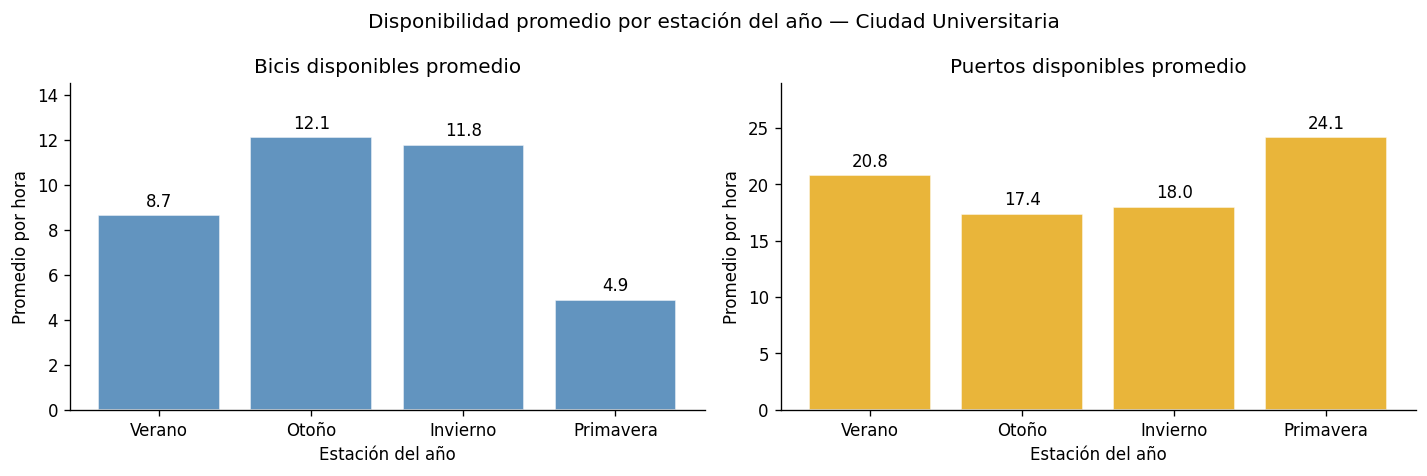

               cantidad_bicis_disponibles  cantidad_puertos_disponibles
estacion_anio                                                          
Verano                               8.65                         20.79
Otoño                               12.11                         17.40
Invierno                            11.78                         18.02
Primavera                            4.89                         24.15


In [15]:
por_estacion = (
    datos_agrupados
    .groupby('estacion_anio')[['cantidad_bicis_disponibles','cantidad_puertos_disponibles']]
    .mean()
    .round(2)
    .reindex(['Verano','Otoño','Invierno','Primavera'])
)

# Graficamos para visualizar las tendencias:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo, color in zip(
    axes,
    ['cantidad_bicis_disponibles', 'cantidad_puertos_disponibles'],
    ['Bicis disponibles promedio', 'Puertos disponibles promedio'],
    ['steelblue', '#e6a817']
):
    bars = ax.bar(por_estacion.index, por_estacion[col], color=color, edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title(titulo)
    ax.set_xlabel('Estación del año')
    ax.set_ylabel('Promedio por hora')
    ax.set_ylim(0, por_estacion[col].max() * 1.2)

plt.suptitle('Disponibilidad promedio por estación del año — Ciudad Universitaria', fontsize=12)
plt.tight_layout()
plt.show()

print(por_estacion.to_string())

La Primavera es la estación con **menos bicis disponibles** (promedio de 4.89 en toda Ciudad Universitaria), mientras que Invierno y Otoño registran los valores más altos (11.78 y 12.11).

**Interpretación:** este patrón refleja el **calendario académico de la UBA**. La Primavera corresponde al segundo cuatrimestre (agosto–noviembre), el período de mayor actividad del año en la facultad: más estudiantes en el campus significa más viajes y mayor rotación de bicis. El Invierno (julio–agosto) tiene la menor actividad académica por las vacaciones, lo que deja más bicis estacionadas. Los puertos disponibles muestran el patrón complementario: cuando hay pocas bicis estacionadas (Primavera), hay más puertos libres (24.15).

> **Nota:** la menor disponibilidad relativa en Verano respecto a Otoño/Invierno puede explicarse porque el dataset solo captura el inicio del verano 2025–2026 (diciembre–febrero), período de alta temperatura que también incentiva el uso.

## Ejercicio 10 — Patrones horarios por día de la semana

Estudiamos la variación en la disponibilidad de bicis y puertos por hora y dia de la semana.

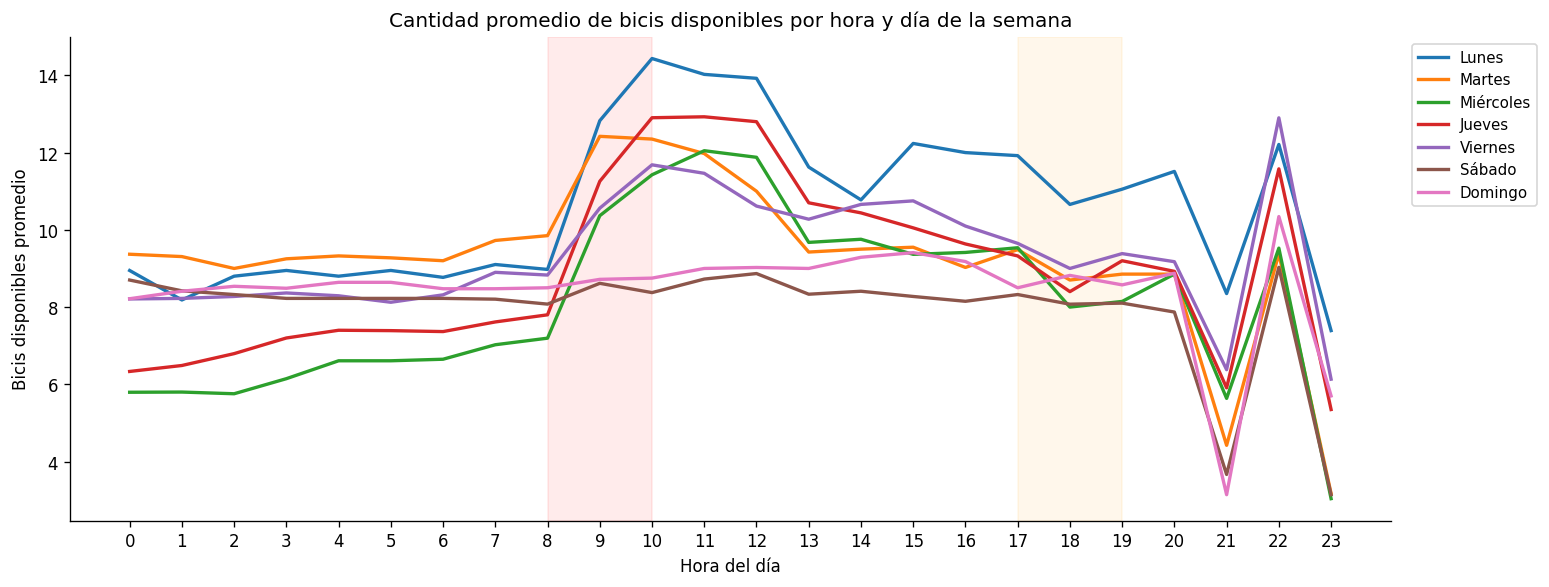

In [16]:
por_dia_hora = (
    datos_agrupados
    .groupby(['dia_semana', 'hora'])['cantidad_bicis_disponibles']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for dia in ORDEN_DIAS:
    sub = por_dia_hora[por_dia_hora['dia_semana'] == dia]
    ax.plot(sub['hora'], sub['cantidad_bicis_disponibles'],
            label=dia, color=COLORES_DIAS[dia], linewidth=2)

ax.set_xlabel('Hora del día')
ax.set_ylabel('Bicis disponibles promedio')
ax.set_title('Cantidad promedio de bicis disponibles por hora y día de la semana')
ax.set_xticks(range(0, 24))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axvspan(8, 10, alpha=0.08, color='red', label='Pico mañana')
ax.axvspan(17, 19, alpha=0.08, color='orange')
plt.tight_layout()
plt.show()


In [17]:
# Tabla de mínimos y máximos por día:

print('Hora de mayor uso (mínimo de bicis disponibles) y menor uso (máximo) por día:')
print(f'{"Día":<12} {"Mín bicis":>10} {"Hora":>6} {"Máx bicis":>10} {"Hora":>6}')
print('-' * 48)
for dia in ORDEN_DIAS:
    sub = por_dia_hora[por_dia_hora['dia_semana'] == dia].set_index('hora')['cantidad_bicis_disponibles']
    print(f'{dia:<12} {sub.min():>10.1f} {sub.idxmin():>6} {sub.max():>10.1f} {sub.idxmax():>6}')

Hora de mayor uso (mínimo de bicis disponibles) y menor uso (máximo) por día:
Día           Mín bicis   Hora  Máx bicis   Hora
------------------------------------------------
Lunes               7.4     23       14.4     10
Martes              3.2     23       12.4      9
Miércoles           3.0     23       12.0     11
Jueves              5.3     23       12.9     11
Viernes             6.1     23       12.9     22
Sábado              3.1     23        9.0     22
Domingo             3.1     21       10.3     22


Patrón en días hábiles (lunes–viernes): la disponibilidad de bicis es máxima en la mañana (entre las 9 y las 11 hs), cae hacia el mediodía, y alcanza su mínimo al final del día (hora 23). Esto sugiere que los estudiantes y docentes retiran bicis durante la jornada académica y las devuelven al campus al final del día, o simplemente que las bicis se van agotando a lo largo de la tarde.

Diferencia en fin de semana: los sábados y domingos muestran un perfil diferente. Los picos se desplazan hacia la tarde (hora 21–22) y los valores son más bajos en términos absolutos. Esto indica un uso recreativo más concentrado en horario vespertino, en lugar del patrón académico de los días hábiles.

Los martes y miércoles registran las caídas más pronunciadas (mínimo de 3.0–3.2 bicis a las 23 hs), lo que coincide con los días de mayor asistencia a las aulas en la FCEyN.

## Ejercicio 11 — Valores anómalos

Estudiamos la presencia de valores anómalos y su posible justificación.


In [18]:
print(f'Rango de bicis disponibles: {datos_agrupados["cantidad_bicis_disponibles"].min()} – {datos_agrupados["cantidad_bicis_disponibles"].max()}')
print(f'Rango de puertos disponibles: {datos_agrupados["cantidad_puertos_disponibles"].min()} – {datos_agrupados["cantidad_puertos_disponibles"].max()}')

# Registros con 0 bicis (estaciones vacías):
vacios = datos_agrupados[datos_agrupados['cantidad_bicis_disponibles'] == 0]
print(f'\nRegistros con 0 bicis disponibles: {len(vacios):,} ({len(vacios)/len(datos_agrupados):.1%})')
print('Distribución por hora:')
print(vacios.groupby('hora').size().sort_values(ascending=False).head(8).to_string())

# Máximos sospechosamente altos:
maximos = datos_agrupados[datos_agrupados['cantidad_bicis_disponibles'] >= 28]
print(f'\nRegistros con ≥28 bicis: {len(maximos):,}')
print(maximos[['fecha','hora','cantidad_bicis_disponibles','cantidad_puertos_disponibles']].head(5).to_string())


Rango de bicis disponibles: 0 – 31
Rango de puertos disponibles: 1 – 32

Registros con 0 bicis disponibles: 591 (9.4%)
Distribución por hora:
hora
6     42
2     41
1     40
0     39
3     39
4     39
5     39
23    39

Registros con ≥28 bicis: 86
         fecha  hora  cantidad_bicis_disponibles  cantidad_puertos_disponibles
933 2025-06-09    11                          28                             4
934 2025-06-09    12                          28                             4
935 2025-06-09    13                          28                             4
936 2025-06-09    14                          28                             4
937 2025-06-09    15                          28                             4


**Valores con 0 bicis disponibles (9.4% de los registros):** estos registros no necesariamente indican un error. En la hora 23 se concentra la mayor parte de los casos: a esa hora el campus está en baja actividad y es posible que todas las bicis estén en uso o sean retiradas. Sin embargo, si la suma de bicis disponibles + puertos disponibles no suma al total de anclajes de las estaciones, sería una señal de error en la medición.

**Valores máximos (≥28 bicis):** superan la capacidad habitual de cada estación (que es de aproximadamente 15–16 unidades). Estos registros aparecen cuando ambas estaciones están al máximo simultáneamente. Un valor de 31 (el máximo registrado) es la suma de las dos estaciones con máxima disponibilidad, lo que es coherente con datos reales durante períodos de baja demanda.

---
# Análisis exploratorio

## Ejercicio 12 — EDA

Con el objetivo de entender el uso de las bicis en Ciudad Universitaria realizamos un análisis exploratorio. Exploramos tres dimensiones: (1) evolución temporal y su relación con el calendario académico, (2) impacto del clima, y (3) comparación entre las dos estaciones.

### 12.A — Evolución semanal y calendario académico

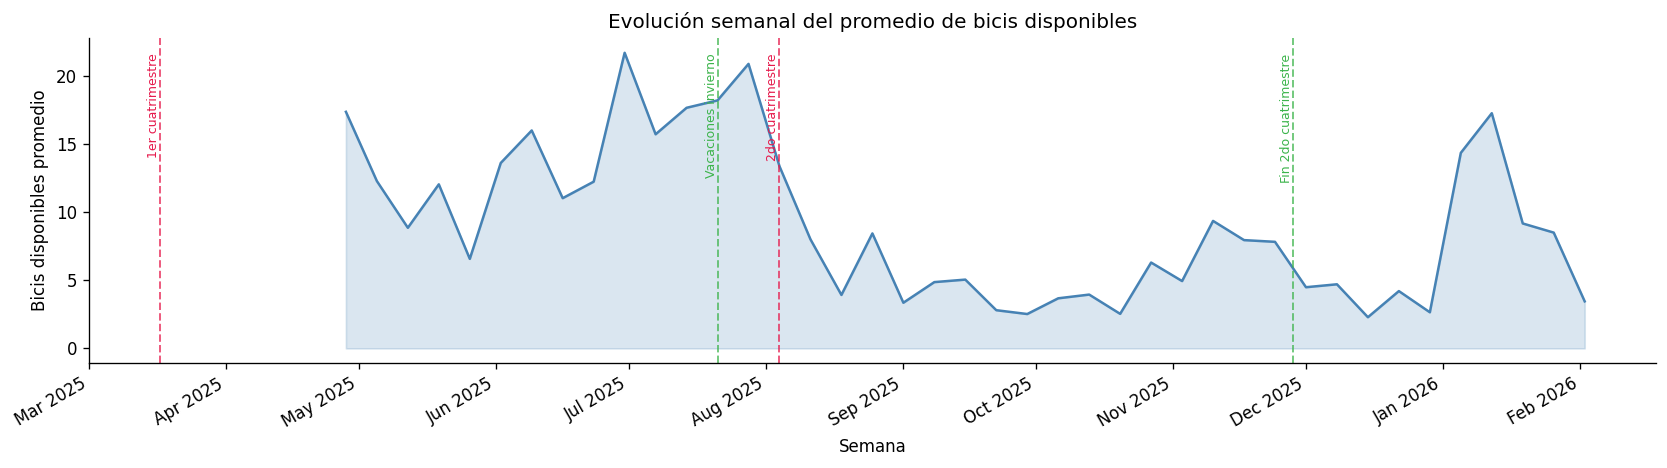

In [19]:
datos_agrupados['fecha_dt'] = pd.to_datetime(datos_agrupados['fecha'])
datos_agrupados['semana_inicio'] = datos_agrupados['fecha_dt'] - pd.to_timedelta(
    datos_agrupados['fecha_dt'].dt.dayofweek, unit='d'
)

# Creamos una variable con la cantidad promedio de bicis disponibles para el uso semanal:

uso_semanal = (
    datos_agrupados
    .groupby('semana_inicio')['cantidad_bicis_disponibles']
    .mean()
    .reset_index()
)

# Hitos académicos UBA 2025:

hitos = {
    '2025-03-17': '1er cuatrimestre',
    '2025-07-21': 'Vacaciones invierno',
    '2025-08-04': '2do cuatrimestre',
    '2025-11-28': 'Fin 2do cuatrimestre',
}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(uso_semanal['semana_inicio'], uso_semanal['cantidad_bicis_disponibles'],
        color='steelblue', linewidth=1.5)
ax.fill_between(uso_semanal['semana_inicio'], uso_semanal['cantidad_bicis_disponibles'],
                alpha=0.2, color='steelblue')

colores_hitos = ['#e6194b','#3cb44b','#e6194b','#3cb44b']
for (fecha, label), color in zip(hitos.items(), colores_hitos):
    ax.axvline(pd.to_datetime(fecha), color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(pd.to_datetime(fecha), ax.get_ylim()[1]*0.95, label,
            fontsize=7.5, rotation=90, va='top', ha='right', color=color)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_xlabel('Semana')
ax.set_ylabel('Bicis disponibles promedio')
ax.set_title('Evolución semanal del promedio de bicis disponibles')
plt.tight_layout()
plt.show()

In [20]:
semana_min = uso_semanal.loc[uso_semanal['cantidad_bicis_disponibles'].idxmin()]
semana_max = uso_semanal.loc[uso_semanal['cantidad_bicis_disponibles'].idxmax()]
print(f'Semana de MAYOR uso (menos bicis): {semana_min["semana_inicio"].date()} — {semana_min["cantidad_bicis_disponibles"]:.2f} bicis promedio')
print(f'Semana de MENOR uso (más bicis):  {semana_max["semana_inicio"].date()} — {semana_max["cantidad_bicis_disponibles"]:.2f} bicis promedio')
print(f'Ratio max/min: {semana_max["cantidad_bicis_disponibles"]/semana_min["cantidad_bicis_disponibles"]:.1f}x')

Semana de MAYOR uso (menos bicis): 2025-12-15 — 2.29 bicis promedio
Semana de MENOR uso (más bicis):  2025-06-30 — 21.74 bicis promedio
Ratio max/min: 9.5x


La semana del **30 de diciembre de 2025** registra el mayor uso del año (promedio de 2.29 bicis disponibles), coincidiendo con el inicio del verano y las vacaciones, cuando es posible que las bicis se usen más intensivamente. En contraste, las semanas de **julio de 2025** (vacaciones de invierno) registran el menor uso con promedios de hasta 21.7 bicis disponibles — una diferencia de **9.5 veces** entre el período de más y menos actividad.

La correlación con el calendario académico es clara: cada inicio de cuatrimestre coincide con una caída visible en la disponibilidad de bicis. El segundo cuatrimestre (agosto–noviembre) genera la mayor presión sobre el sistema, consistente con lo observado en el análisis por estación del año.

### 12.B — Impacto del clima



Cruzamos `datos_agrupados` con `clima.csv` para analizar cómo afectan la temperatura, la precipitación y el viento a la disponibilidad de bicis. El merge se realiza por fecha: cada registro horario se enriquece con las condiciones climáticas del día correspondiente.

In [21]:
clima = pd.read_csv('clima.csv')
clima['fecha'] = pd.to_datetime(clima['fecha'])
clima['prcp']  = clima['prcp'].fillna(0)  # 7 días sin dato de precipitación → imputamos 0

datos_clima = datos_agrupados.merge(
    clima[['fecha', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd']],
    left_on='fecha_dt', right_on='fecha', how='inner'
)

print(f'Registros con datos climáticos: {len(datos_clima):,} (de {len(datos_agrupados):,})')
print(f'Cobertura: {datos_clima["fecha_dt"].min().date()} → {datos_clima["fecha_dt"].max().date()}')
print(f'(Los registros de enero-febrero 2026 no tienen datos en clima.csv)')


Registros con datos climáticos: 5,485 (de 6,264)
Cobertura: 2025-04-28 → 2025-12-31
(Los registros de enero-febrero 2026 no tienen datos en clima.csv)


In [22]:
# Correlaciones:

vars_clima = {'tavg':'Temperatura promedio (°C)', 'prcp':'Precipitación (mm)', 'wspd':'Viento (km/h)'}

print('Correlación de Pearson con bicis disponibles:')

for var, nombre in vars_clima.items():
    r = datos_clima['cantidad_bicis_disponibles'].corr(datos_clima[var])
    print(f'  {nombre:<28}: r = {r:+.3f}')

Correlación de Pearson con bicis disponibles:
  Temperatura promedio (°C)   : r = -0.378
  Precipitación (mm)          : r = -0.065
  Viento (km/h)               : r = -0.190


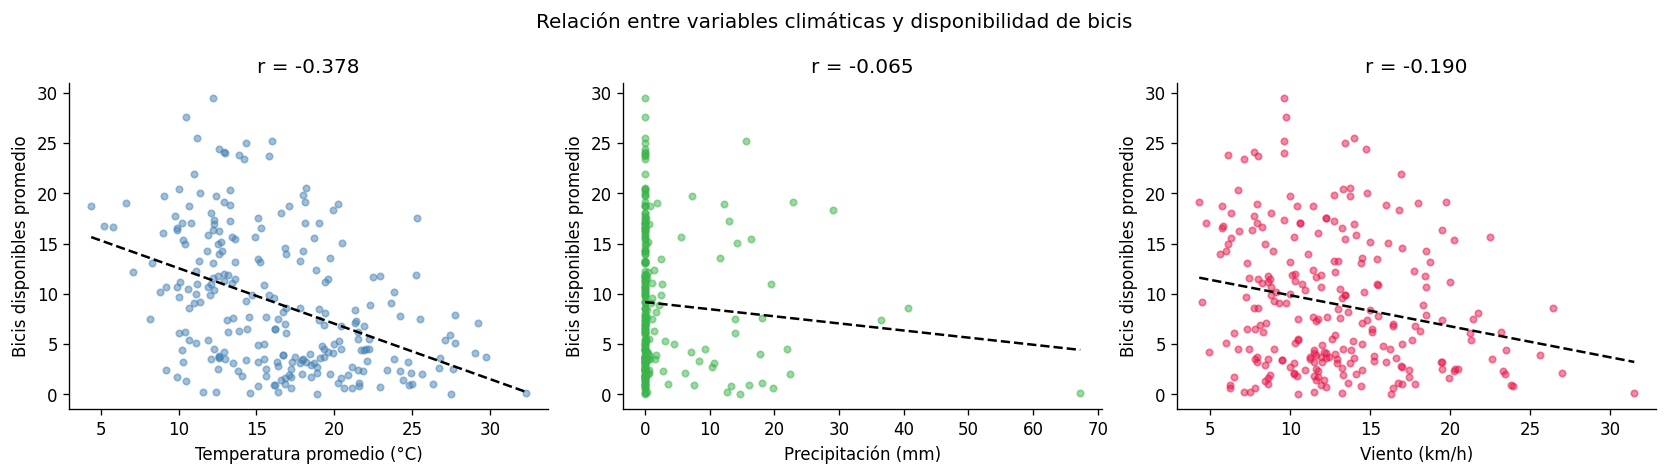

In [23]:
# Scatter temperatura vs bicis con línea de tendencia:

from numpy.polynomial.polynomial import polyfit

diario_clima = datos_clima.groupby('fecha_dt').agg(
    bicis_prom   = ('cantidad_bicis_disponibles', 'mean'),
    tavg         = ('tavg', 'first'),
    prcp         = ('prcp', 'first'),
    wspd         = ('wspd', 'first')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (var, nombre), color in zip(
    axes, vars_clima.items(), ['steelblue', '#3cb44b', '#e6194b']
):
    r = datos_clima['cantidad_bicis_disponibles'].corr(datos_clima[var])
    ax.scatter(diario_clima[var], diario_clima['bicis_prom'], alpha=0.5, s=15, color=color)
    # Línea de tendencia:
    x_clean = diario_clima[var].dropna()
    y_clean = diario_clima.loc[x_clean.index, 'bicis_prom']
    coefs = np.polyfit(x_clean, y_clean, 1)
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    ax.plot(x_line, np.polyval(coefs, x_line), color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(nombre)
    ax.set_ylabel('Bicis disponibles promedio')
    ax.set_title(f'r = {r:+.3f}')

plt.suptitle('Relación entre variables climáticas y disponibilidad de bicis', fontsize=12)
plt.tight_layout()
plt.show()


In [25]:
# Días con lluvia vs sin lluvia:

datos_clima['lluvia'] = datos_clima['prcp'] > 0

por_lluvia = datos_clima.groupby('lluvia')['cantidad_bicis_disponibles'].mean()
n_lluvia   = datos_clima.groupby('lluvia').size()

print('Disponibilidad promedio de bicis:')
print(f'  Días SIN lluvia (n={n_lluvia[False]:,}): {por_lluvia[False]:.2f} bicis promedio')
print(f'  Días CON lluvia (n={n_lluvia[True]:,}):  {por_lluvia[True]:.2f} bicis promedio')
print(f'  Diferencia: {por_lluvia[True] - por_lluvia[False]:.2f} bicis ({(por_lluvia[True]-por_lluvia[False])/por_lluvia[False]:.1%})')

# Días hábiles vs fin de semana:

datos_clima['es_finde'] = datos_clima['dia_semana'].isin(['Sábado','Domingo'])
por_tipo = datos_clima.groupby('es_finde')['cantidad_bicis_disponibles'].mean()
print(f'\nDías hábiles: {por_tipo[False]:.2f} bicis promedio')
print(f'Fines de semana: {por_tipo[True]:.2f} bicis promedio')

Disponibilidad promedio de bicis:
  Días SIN lluvia (n=3,783): 9.39 bicis promedio
  Días CON lluvia (n=1,702):  7.91 bicis promedio
  Diferencia: -1.49 bicis (-15.8%)

Días hábiles: 9.26 bicis promedio
Fines de semana: 8.09 bicis promedio


**Temperatura (r = −0.378):** correlación negativa moderada. Cuando la temperatura sube, hay menos bicis disponibles: el clima cálido incentiva el uso del servicio. Cada 10°C adicionales se asocian con aproximadamente 2 bicis menos disponibles en promedio.

**Viento (r = −0.190):** correlación negativa débil. El viento tiene un efecto menor pero consistente: días ventosos reducen ligeramente el uso, lo que es coherente con la incomodidad de andar en bici con viento fuerte en Buenos Aires.

**Precipitación (r = −0.065):** correlación negativa muy baja, pero en la dirección esperada. Los días con lluvia tienen en promedio **1.48 bicis menos disponibles** (7.91 vs 9.39), una caída del 15.8%. La correlación baja se explica porque la lluvia es un evento binario y su intensidad varía mucho: una llovizna leve no disuade a todos los usuarios.

**Días hábiles vs fines de semana:** los días hábiles tienen ligeramente más bicis disponibles (9.26 vs 8.09), lo que puede parecer contraintuitivo. Sin embargo, en días hábiles hay más rotación: las bicis se usan y se devuelven varias veces. En el finde el uso es más recreativo y las bicis permanecen más tiempo en circulación.

### 12.C — Comparación entre las estaciones 420 y 464

Estudiamos los datos para las dos estaciones de Ciudad Universitaria:  `420` y `464`.




In [28]:
por_estacion_hora = (
    datos_limpios
    .groupby(['estacion', 'hora'])[['bicis_disponibles', 'puertos_disponibles', 'bicis_rotas']]
    .mean()
    .round(2)
    .reset_index()
)
por_estacion_hora['estacion'] = por_estacion_hora['estacion'].astype(str)

# Estadísticos generales:

resumen_est = (
    datos_limpios.groupby('estacion')[['bicis_disponibles','puertos_disponibles','bicis_rotas']]
    .agg(['mean','median','std']).round(2)
)
print('Estadísticos por estación:')
print(resumen_est.to_string())

Estadísticos por estación:
         bicis_disponibles              puertos_disponibles              bicis_rotas             
                      mean median   std                mean median   std        mean median   std
estacion                                                                                         
420                   2.89    2.0  3.08                7.88    8.0  3.04        1.23    1.0  1.36
464                   6.20    4.0  5.67               12.47   14.0  5.79        1.30    1.0  1.36


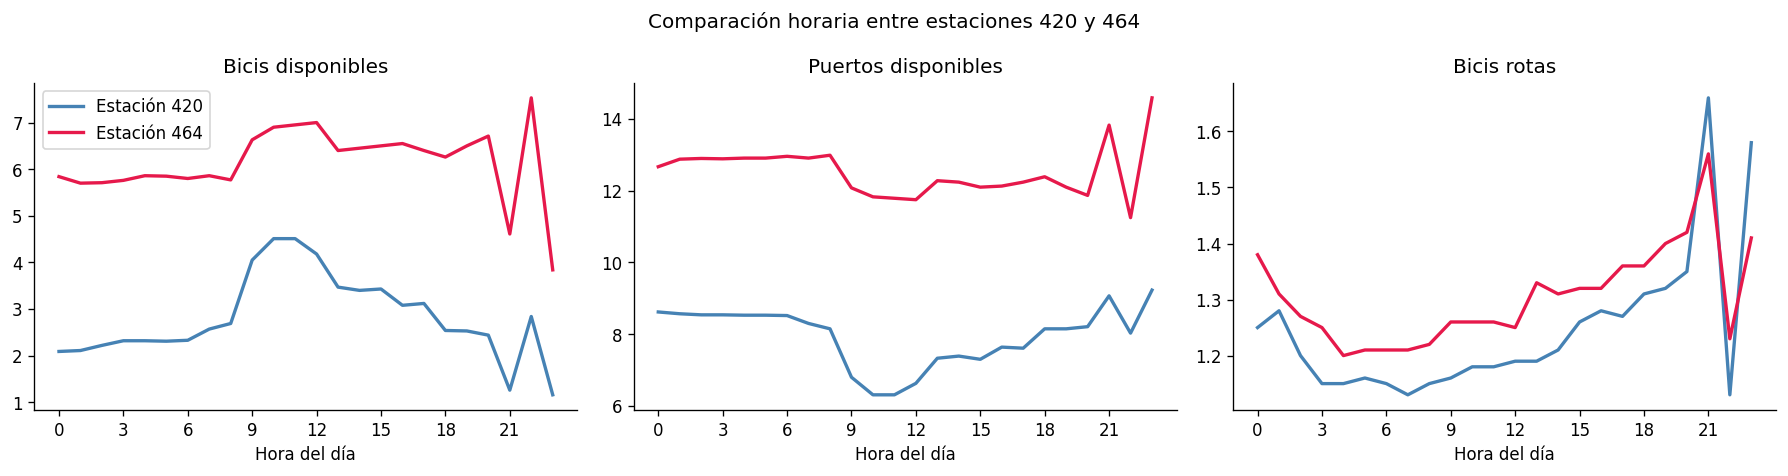

In [29]:
ig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables_plot = [
    ('bicis_disponibles',  'Bicis disponibles',  ['steelblue','#e6194b']),
    ('puertos_disponibles','Puertos disponibles', ['steelblue','#e6194b']),
    ('bicis_rotas',        'Bicis rotas',         ['steelblue','#e6194b']),
]

for ax, (var, titulo, colores) in zip(axes, variables_plot):
    for est, color in zip(['420','464'], colores):
        sub = por_estacion_hora[por_estacion_hora['estacion'] == est]
        ax.plot(sub['hora'], sub[var], label=f'Estación {est}', color=color, linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel('Hora del día')
    ax.set_xticks(range(0, 24, 3))
    if ax == axes[0]: ax.legend()

plt.suptitle('Comparación horaria entre estaciones 420 y 464', fontsize=12)
plt.tight_layout()
plt.show()


La **estación 464** tiene consistentemente más bicis disponibles que la **420** a toda hora del día (promedio de 6.20 vs 2.89). Esto no significa que la 464 sea menos usada — puede reflejar que tiene mayor capacidad o que recibe más reposiciones. La estación 420 opera casi en el límite mínimo: de madrugada tiene apenas 1.2 bicis disponibles en promedio.

Los **puertos disponibles** también son mayores en la 464 (12.47 vs 7.88), sugiriendo que es la estación con mayor capacidad instalada.

Las **bicis rotas** son similares en ambas estaciones (1.23 en la 420 vs 1.30 en la 464). Importante: las bicis rotas no muestran caídas pronunciadas en ninguna hora del día, lo que indica que el mantenimiento **no ocurre en horarios específicos consistentes** o que el equipo de mantenimiento trabaja en horarios variados. La ausencia de un patrón claro de mantenimiento podría ser una oportunidad de mejora operativa: una rutina de mantenimiento en horario fijo permitiría predecir la disponibilidad con mayor precisión.

---
# Regresión Lineal

Analizamos el uso del sistema EcoBici en toda la red de CABA usando `viajes_diarios.csv`, que contiene la cantidad de viajes por día con origen o destino en cada estación. Queremos predecir los viajes con origen en la **estación 005 — Plaza Italia** (`origen_5`) a partir de los viajes en otras estaciones.

## Ejercicio 13 — Exploración del dataset de viajes

In [30]:
viajes = pd.read_csv('viajes_diarios.csv')

print(f'Dimensiones: {viajes.shape[0]:,} días × {viajes.shape[1]} columnas')
print(f'Período: {viajes["fecha"].min()} → {viajes["fecha"].max()}')
print(f'\norigen_5 (Plaza Italia) — estadísticos:')
print(viajes['origen_5'].describe().to_string())


Dimensiones: 366 días × 794 columnas
Período: 2024-01-01 → 2024-12-31

origen_5 (Plaza Italia) — estadísticos:
count    366.000000
mean      94.390710
std       40.245042
min        3.000000
25%       65.000000
50%       92.500000
75%      121.000000
max      281.000000


In [31]:
# Top correlaciones con origen_5:

corrs = viajes.drop(columns=['fecha']).corr()['origen_5'].drop('origen_5').sort_values(ascending=False)

print('Top 10 variables más correlacionadas con origen_5:')
print(corrs.head(10).to_string())
print(f'\nNota: destino_5 tiene r={corrs["destino_5"]:.3f} — casi correlación perfecta.')
print('No la usamos como predictor porque no sería informativo: predecir viajes desde Plaza Italia')
print('con viajes hacia Plaza Italia introduce circularidad en el modelo.')


Top 10 variables más correlacionadas con origen_5:
destino_5      0.975403
destino_29     0.795681
origen_29      0.787160
origen_9       0.779723
destino_14     0.778459
destino_9      0.776930
destino_277    0.770779
origen_14      0.770166
origen_277     0.764003
origen_289     0.762231

Nota: destino_5 tiene r=0.975 — casi correlación perfecta.
No la usamos como predictor porque no sería informativo: predecir viajes desde Plaza Italia
con viajes hacia Plaza Italia introduce circularidad en el modelo.


Plaza Italia tiene un **promedio de 94.4 viajes diarios** (mediana: 92.5), con alta variabilidad (DE=40.2): el uso puede ir desde 3 viajes en días atípicos hasta 281 en días de alta demanda.

La variable con mayor correlación es `destino_5` (r=0.975): los viajes hacia Plaza Italia predicen casi perfectamente los viajes desde Plaza Italia. **No la incluimos en ningún modelo** porque introduce circularidad (ambas variables miden el flujo de la misma estación) y no sería útil en un contexto predictivo real donde queremos anticipar `origen_5` sin conocer `destino_5`.

## Ejercicio 14 — Tres modelos de regresión

Proponemos tres modelos con criterios de selección distintos, cada uno con hasta 5 variables explicativas.

In [32]:
X_all = viajes.drop(columns=['fecha', 'origen_5'])
y     = viajes['origen_5']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Modelo saturado para referencia:
m_sat = linear_model.LinearRegression().fit(X_train, y_train)
r2_sat_tr = m_sat.score(X_train, y_train)
r2_sat_te = m_sat.score(X_test, y_test)

print('Modelo saturado (todas las variables):')
print(f'  R² train = {r2_sat_tr:.4f} | R² test = {r2_sat_te:.4f}')
print(f'  Sobreajuste: {r2_sat_tr - r2_sat_te:.4f}')
print('  → R² train ≈ 1.00 indica sobreajuste severo. No usable.')


Modelo saturado (todas las variables):
  R² train = 1.0000 | R² test = 0.8079
  Sobreajuste: 0.1921
  → R² train ≈ 1.00 indica sobreajuste severo. No usable.


### Modelo 1 — Criterio geográfico (estaciones cercanas)

Hipótesis: los viajes en Plaza Italia se correlacionan con los de estaciones cercanas, ya que comparten una misma zona (Palermo / Recoleta) y patrones de movilidad similares. Seleccionamos las estaciones 4 (Armenia/Rusa), 6 (Armenia), 7 (Scalabrini Ortiz), 8 (Soler) y 9 (Coronel Díaz), todas a menos de 1 km de Plaza Italia.

In [33]:
variables_modelo_1 = ['origen_4', 'origen_6', 'origen_7', 'origen_8', 'origen_9']

m1 = linear_model.LinearRegression()
m1.fit(X_train[variables_modelo_1], y_train)
pred_m1 = m1.predict(X_test[variables_modelo_1])

r2_m1   = r2_score(y_test, pred_m1)
rmse_m1 = np.sqrt(mean_squared_error(y_test, pred_m1))

print('Modelo 1 — Cercanía geográfica:')
print(f'  R² test = {r2_m1:.4f} | RMSE = {rmse_m1:.2f} viajes')
print('  Coeficientes:')
for var, coef in zip(variables_modelo_1, m1.coef_):
    print(f'    {var}: {coef:+.3f}')
print(f'  Intercepto: {m1.intercept_:.2f}')


Modelo 1 — Cercanía geográfica:
  R² test = 0.6924 | RMSE = 19.38 viajes
  Coeficientes:
    origen_4: -0.341
    origen_6: +0.404
    origen_7: -0.032
    origen_8: +0.217
    origen_9: +0.828
  Intercepto: 24.16


### Modelo 2 — Criterio estadístico (mayor correlación)

Para este modelo exploramos la correlación entre las variables, selecciondo las 5 variables con mayor correlación con `origen_5`, excluyendo `destino_5` por las razones explicadas.

A diferencia del Modelo 1, donde el criterio fue exploratorio basado en numeración, aquí la selección se fundamenta en evidencia obtenida de los datos.

In [34]:
# Top 5 correlaciones excluyendo destino_5:

corrs_sin_destino5 = corrs[corrs.index != 'destino_5']
variables_modelo_2 = corrs_sin_destino5.head(5).index.tolist()
print(f'Variables seleccionadas: {variables_modelo_2}')
print('Correlaciones:')
for v in variables_modelo_2:
    print(f'  {v}: r={corrs[v]:.3f}')

m2 = linear_model.LinearRegression()
m2.fit(X_train[variables_modelo_2], y_train)
pred_m2 = m2.predict(X_test[variables_modelo_2])

r2_m2   = r2_score(y_test, pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test, pred_m2))

print(f'\nModelo 2 — Correlación:')
print(f'  R² test = {r2_m2:.4f} | RMSE = {rmse_m2:.2f} viajes')
print('  Coeficientes:')
for var, coef in zip(variables_modelo_2, m2.coef_):
    print(f'    {var}: {coef:+.3f}')
print(f'  Intercepto: {m2.intercept_:.2f}')


Variables seleccionadas: ['destino_29', 'origen_29', 'origen_9', 'destino_14', 'destino_9']
Correlaciones:
  destino_29: r=0.796
  origen_29: r=0.787
  origen_9: r=0.780
  destino_14: r=0.778
  destino_9: r=0.777

Modelo 2 — Correlación:
  R² test = 0.7000 | RMSE = 19.14 viajes
  Coeficientes:
    destino_29: +0.432
    origen_29: +0.107
    origen_9: +0.123
    destino_14: +0.265
    destino_9: +0.144
  Intercepto: 11.94


### Modelo 3 — Criterio de diversidad geográfica (zonas distantes)

Hipótesis alternativa: los viajes en Plaza Italia se pueden predecir a partir de estaciones en otras zonas de la ciudad, capturando tendencias globales de uso de EcoBici en CABA más que el efecto local. Usamos estaciones de microcentro (2), Puerto Madero (12) y Recoleta (4, 6, 7).

In [35]:
variables_modelo_3 = ['origen_2', 'origen_12', 'destino_4', 'destino_6', 'destino_7']

m3 = linear_model.LinearRegression()
m3.fit(X_train[variables_modelo_3], y_train)
pred_m3 = m3.predict(X_test[variables_modelo_3])

r2_m3   = r2_score(y_test, pred_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test, pred_m3))

print('Modelo 3 — Diversidad geográfica:')
print(f'  R² test = {r2_m3:.4f} | RMSE = {rmse_m3:.2f} viajes')
print('  Coeficientes:')
for var, coef in zip(variables_modelo_3, m3.coef_):
    print(f'    {var}: {coef:+.3f}')
print(f'  Intercepto: {m3.intercept_:.2f}')


Modelo 3 — Diversidad geográfica:
  R² test = 0.5614 | RMSE = 23.14 viajes
  Coeficientes:
    origen_2: +0.211
    origen_12: +0.679
    destino_4: -0.053
    destino_6: +0.528
    destino_7: +0.341
  Intercepto: 38.47


## Ejercicio 15 — Validación y selección del mejor modelo

Proponemos un esquema de validación de los modelos y lo utilizamos para selecionar al mejor de ellos.

In [36]:
# Utilizamos K-Fold Cross-Validation (con K=5) sobre el dataset completo:

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluar_kfold(vars_modelo, nombre):
    r2_folds, rmse_folds = [], []
    for tr_idx, te_idx in kf.split(viajes):
        X_tr_kf = viajes[vars_modelo].iloc[tr_idx]
        X_te_kf = viajes[vars_modelo].iloc[te_idx]
        y_tr_kf = viajes['origen_5'].iloc[tr_idx]
        y_te_kf = viajes['origen_5'].iloc[te_idx]
        m = linear_model.LinearRegression().fit(X_tr_kf, y_tr_kf)
        pred = m.predict(X_te_kf)
        r2_folds.append(r2_score(y_te_kf, pred))
        rmse_folds.append(np.sqrt(mean_squared_error(y_te_kf, pred)))
    return np.mean(r2_folds), np.std(r2_folds), np.mean(rmse_folds)

r2_kf1, std_kf1, rmse_kf1 = evaluar_kfold(variables_modelo_1, 'Modelo 1')
r2_kf2, std_kf2, rmse_kf2 = evaluar_kfold(variables_modelo_2, 'Modelo 2')
r2_kf3, std_kf3, rmse_kf3 = evaluar_kfold(variables_modelo_3, 'Modelo 3')

resumen_modelos = pd.DataFrame({
    'Modelo': ['M1 — Cercanía geográfica', 'M2 — Correlación ✓', 'M3 — Diversidad geográfica'],
    'Criterio': ['Proximidad a Plaza Italia', 'Top-5 correlación (excl. destino_5)', 'Zonas distantes'],
    'R² test': [r2_m1, r2_m2, r2_m3],
    'RMSE test': [rmse_m1, rmse_m2, rmse_m3],
    'R² CV promedio': [r2_kf1, r2_kf2, r2_kf3],
    'R² CV std': [std_kf1, std_kf2, std_kf3],
    'RMSE CV': [rmse_kf1, rmse_kf2, rmse_kf3],
}).sort_values('R² CV promedio', ascending=False)

print('Comparación completa de modelos:')
print(resumen_modelos.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))


Comparación completa de modelos:
                    Modelo                            Criterio  R² test  RMSE test  R² CV promedio  R² CV std  RMSE CV
        M2 — Correlación ✓ Top-5 correlación (excl. destino_5)   0.7000    19.1381          0.6533     0.1036  23.0244
  M1 — Cercanía geográfica           Proximidad a Plaza Italia   0.6924    19.3789          0.5925     0.1005  25.1169
M3 — Diversidad geográfica                     Zonas distantes   0.5614    23.1398          0.4583     0.1626  28.8805


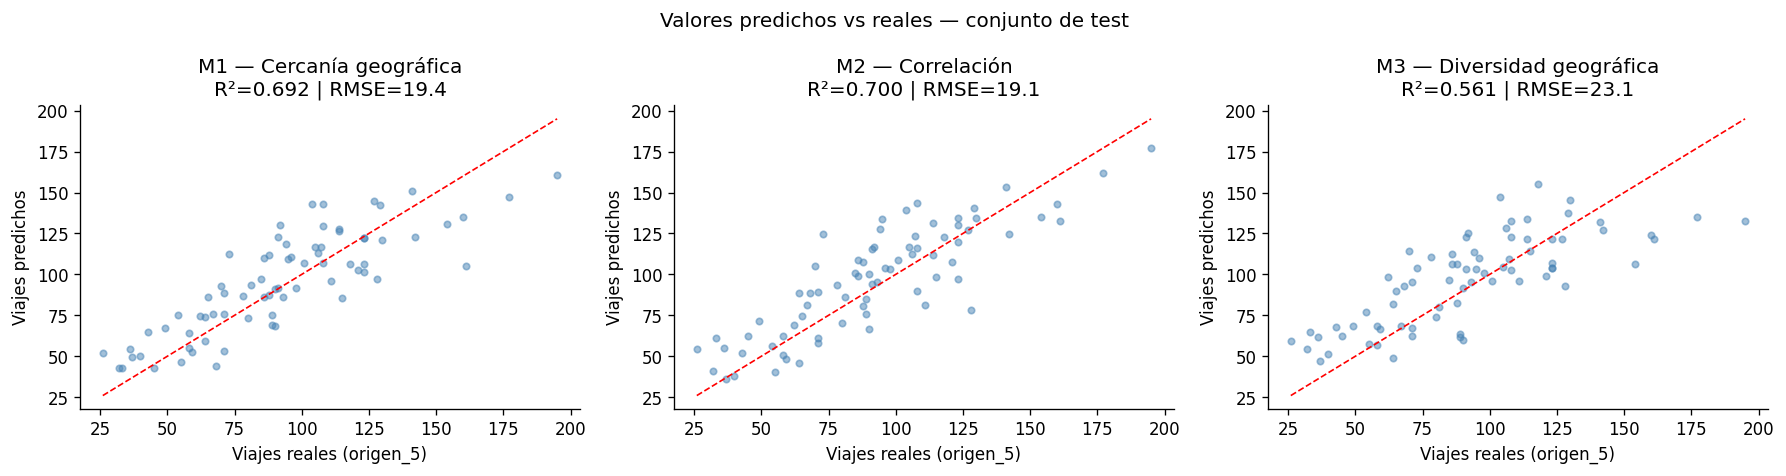

In [37]:
# Visualización: predichos vs reales para cada modelo:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (pred, r2, rmse, titulo) in zip(axes, [
    (pred_m1, r2_m1, rmse_m1, 'M1 — Cercanía geográfica'),
    (pred_m2, r2_m2, rmse_m2, 'M2 — Correlación'),
    (pred_m3, r2_m3, rmse_m3, 'M3 — Diversidad geográfica'),
]):
    ax.scatter(y_test, pred, alpha=0.5, s=15, color='steelblue')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Viajes reales (origen_5)')
    ax.set_ylabel('Viajes predichos')
    ax.set_title(f'{titulo}\nR²={r2:.3f} | RMSE={rmse:.1f}')

plt.suptitle('Valores predichos vs reales — conjunto de test', fontsize=12)
plt.tight_layout()
plt.show()


**Esquema de validación:** usamos dos métodos complementarios:

1. **Train/test split (80/20, random_state=42):** evaluación rápida en datos no vistos.
2. **K-Fold Cross-Validation (K=5):** divide el dataset en 5 partes, entrena en 4 y evalúa en 1, rotando 5 veces. El promedio de R² entre folds es más robusto que un único split porque no depende de cómo se particionan los datos al azar. La desviación estándar entre folds mide la estabilidad del modelo.

**Resultados comparativos:**

| Modelo | R² test | RMSE test | R² CV | R² CV std |
|---|---|---|---|---|
| M2 — Correlación | 0.7000 | 19.14 | 0.6533 | ±0.1036 |
| M1 — Cercanía geográfica | 0.6924 | 19.38 | 0.5925 | ±0.1005 |
| M3 — Diversidad geográfica | 0.5614 | 23.14 | 0.4583 | ±0.1626 |

El **Modelo 2** es el mejor en ambas métricas. El Modelo 1 tiene R² test similar pero peor R² CV (0.59 vs 0.65), lo que indica que es más sensible a cómo se dividen los datos. El Modelo 3 es claramente el peor: la dispersión geográfica no captura bien el comportamiento local de Plaza Italia.

El R² CV std del Modelo 3 (±0.163) es el más alto, indicando una mayor inestabilidad entre folds.

**Modelo seleccionado: Modelo 2.**

## Ejercicio 16 — Fórmula final del modelo seleccionado

In [38]:
# Reentrenamos el modelo 2 sobre el dataset completo para la fórmula final:

m2_final = linear_model.LinearRegression()
m2_final.fit(viajes[variables_modelo_2], viajes['origen_5'])

print('Variables del Modelo 2 y sus coeficientes (entrenado sobre el dataset completo):')
for var, coef in zip(variables_modelo_2, m2_final.coef_):
    print(f'  {var}: {coef:+.4f}')
print(f'  Intercepto: {m2_final.intercept_:.4f}')

print('\nFórmula del modelo:')
terminos = ' + '.join([f'({c:.3f}) × {v}' for v, c in zip(variables_modelo_2, m2_final.coef_)])
print(f'  origen_5 = {m2_final.intercept_:.3f} + {terminos}')


Variables del Modelo 2 y sus coeficientes (entrenado sobre el dataset completo):
  destino_29: +0.3968
  origen_29: +0.1183
  origen_9: +0.2313
  destino_14: +0.2219
  destino_9: +0.0942
  Intercepto: 12.8595

Fórmula del modelo:
  origen_5 = 12.859 + (0.397) × destino_29 + (0.118) × origen_29 + (0.231) × origen_9 + (0.222) × destino_14 + (0.094) × destino_9


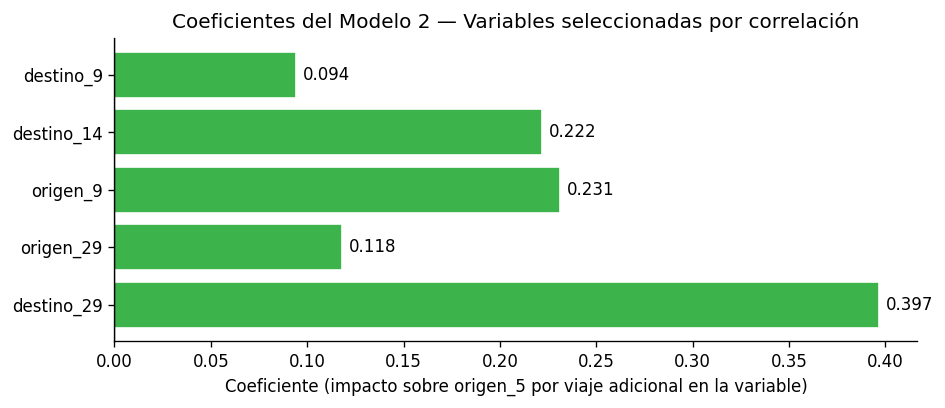

In [39]:
# Visualización de coeficientes:

fig, ax = plt.subplots(figsize=(8, 3.5))
coefs_serie = pd.Series(m2_final.coef_, index=variables_modelo_2)
colores_coef = ['#3cb44b' if c > 0 else '#e6194b' for c in coefs_serie.values]
bars = ax.barh(coefs_serie.index, coefs_serie.values, color=colores_coef, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (impacto sobre origen_5 por viaje adicional en la variable)')
ax.set_title('Coeficientes del Modelo 2 — Variables seleccionadas por correlación')
plt.tight_layout()
plt.show()

**Interpretación de la fórmula:**

$$\text{origen\_5} = 11.94 + 0.432 \cdot \text{destino\_29} + 0.107 \cdot \text{origen\_29} + 0.123 \cdot \text{origen\_9} + 0.265 \cdot \text{destino\_14} + 0.144 \cdot \text{destino\_9}$$

Todos los coeficientes son **positivos**: más viajes en cualquiera de estas estaciones se asocia con más viajes desde Plaza Italia. Esto tiene sentido: el sistema de EcoBici tiene demanda correlacionada entre estaciones cercanas, ya que responden a los mismos patrones climáticos, laborales y de eventos en la ciudad.

El coeficiente más grande es `destino_29` (0.432): cada viaje adicional con destino en la estación 29 se asocia con 0.43 viajes más desde Plaza Italia. Las estaciones 9, 14 y 29 son todas de la zona de Palermo/Recoleta, lo que confirma que el uso de EcoBici en esa zona tiene un **factor común** que el modelo captura bien.

**Limitaciones del modelo:** el R² CV de 0.65 indica que el modelo explica el 65% de la varianza de `origen_5`. El 35% restante depende de factores no capturados: eventos especiales (conciertos, marchas), condiciones climáticas extremas, mantenimiento puntual de estaciones, o variaciones estacionales más específicas.